In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import xarray as xr

sys.path.append(os.path.abspath('../scripts'))
import ocean_analysis as oa 

In [ ]:
# import numpy as np
# import xarray as xr


# def calculate_EDS(
#     filepath,
#     target_box=None,
#     max_wavelength_km=None,
#     initialized_velocity=False,
#     x_res=None,
#     y_res=None,
#     n_bins=8,
#     remove_mean=True,
#     temporal_window_days=7,
#     temporal_skip_days=0,
#     temporal_stride_days=1,
#     min_modes_per_bin=3,
#     rose_scale_bands_km=None,
#     rose_n_angle_bins=12,
# ):
#     """
#     Compute spectra from a small 2D velocity field.

#     Main outputs
#     ------------
#     shell_integrated_spectrum(wavenumber)
#         Total KE in each radial shell.
#         Best for scale-bridging / "where does the energy sit by scale?"

#     spectral_density(wavenumber)
#         Shell-integrated spectrum divided by dk.
#         Best for comparing slope shape in k-space, not absolute magnitude.

#     dominant_axis_deg(wavenumber)
#         Preferred axis from doubled-angle circular moment.

#     anisotropy_strength(wavenumber)
#         Magnitude of doubled-angle circular moment, between 0 and 1.

#     rose_spectrum(scale_band, rose_angle_deg)
#         Angular energy for selected broad scale bands.

#     rose_spectrum_normalized(scale_band, rose_angle_deg)
#         Same, normalized within each scale band.

#     Notes
#     -----
#     - No spatial windowing is applied.
#     - Wavenumbers are in cycles per meter.
#     - characteristic_length = 1 / wavenumber
#     - Temporal smoothing is done by averaging spectra over temporal windows.
#     """

#     ds = xr.open_dataset(filepath)

#     # ------------------------------------------------------------
#     # 1. Select box and infer spacing
#     # ------------------------------------------------------------
#     if initialized_velocity:
#         if target_box is None:
#             box_ds = ds.isel(depth=0)
#         else:
#             box_ds = ds.sel(
#                 x=slice(target_box[0], target_box[1]),
#                 y=slice(target_box[2], target_box[3]),
#             ).isel(depth=0)

#         x = box_ds.x.values
#         y = box_ds.y.values

#         if x_res is None:
#             x_res = float(np.abs(np.mean(np.gradient(x))))
#         if y_res is None:
#             y_res = float(np.abs(np.mean(np.gradient(y))))

#         dx = x_res
#         dy = y_res
#         nx = len(x)
#         ny = len(y)

#     else:
#         if target_box is None:
#             box_ds = ds.isel(depth=0)
#         else:
#             box_ds = ds.sel(
#                 longitude=slice(target_box[0], target_box[1]),
#                 latitude=slice(target_box[2], target_box[3]),
#             ).isel(depth=0)

#         R_earth = 6371000.0
#         phi_lat = float(box_ds.latitude.mean())

#         dlat_deg = np.abs(np.mean(np.gradient(box_ds.latitude.values)))
#         dlon_deg = np.abs(np.mean(np.gradient(box_ds.longitude.values)))

#         dy = np.deg2rad(dlat_deg) * R_earth
#         dx = np.deg2rad(dlon_deg) * R_earth * np.cos(np.deg2rad(phi_lat))

#         ny = len(box_ds.latitude)
#         nx = len(box_ds.longitude)

#     if "time" not in box_ds.dims:
#         raise ValueError("Dataset must contain a time dimension.")

#     # ------------------------------------------------------------
#     # 2. Wavenumber grid
#     # ------------------------------------------------------------
#     kx = np.fft.fftfreq(nx, d=dx)
#     ky = np.fft.fftfreq(ny, d=dy)
#     kx_grid, ky_grid = np.meshgrid(kx, ky, indexing="xy")

#     k_mag = np.sqrt(kx_grid**2 + ky_grid**2)
#     theta_rad = np.arctan2(ky_grid, kx_grid)

#     valid_k = k_mag > 0
#     if not np.any(valid_k):
#         raise ValueError("No valid nonzero wavenumbers found.")

#     Lx = nx * dx
#     Ly = ny * dy
#     natural_lambda_max = min(Lx, Ly)

#     if max_wavelength_km is None:
#         lambda_max = natural_lambda_max
#     else:
#         lambda_max = min(max_wavelength_km * 1000.0, natural_lambda_max)

#     k_min = 1.0 / lambda_max
#     k_max = np.nanmax(k_mag[valid_k])

#     if k_min >= k_max:
#         raise ValueError("Selected max wavelength is too small relative to the domain/grid.")

#     k_bins = np.logspace(np.log10(k_min), np.log10(k_max), num=n_bins + 1)
#     k_centers = np.sqrt(k_bins[:-1] * k_bins[1:])
#     dk = np.diff(k_bins)

#     shell_masks = []
#     shell_mode_count = np.zeros(n_bins, dtype=int)
#     for i in range(n_bins):
#         shell = (k_mag >= k_bins[i]) & (k_mag < k_bins[i + 1])
#         shell_masks.append(shell)
#         shell_mode_count[i] = int(np.sum(shell))

#     # ------------------------------------------------------------
#     # 3. Rose band setup
#     # ------------------------------------------------------------
#     rose_enabled = rose_scale_bands_km is not None and len(rose_scale_bands_km) > 0

#     if rose_enabled:
#         rose_scale_bands_km = [tuple(b) for b in rose_scale_bands_km]
#         n_rose_bands = len(rose_scale_bands_km)

#         rose_angle_edges_deg = np.linspace(-180.0, 180.0, rose_n_angle_bins + 1)
#         rose_angle_centers_deg = 0.5 * (rose_angle_edges_deg[:-1] + rose_angle_edges_deg[1:])

#         rose_band_masks = []
#         rose_band_labels = []

#         for lam_hi_km, lam_lo_km in rose_scale_bands_km:
#             if lam_hi_km <= lam_lo_km:
#                 raise ValueError("Each rose scale band must be (larger_km, smaller_km).")
#             k_lo = 1.0 / (lam_hi_km * 1000.0)
#             k_hi = 1.0 / (lam_lo_km * 1000.0)
#             mask = (k_mag >= k_lo) & (k_mag < k_hi)
#             rose_band_masks.append(mask)
#             rose_band_labels.append(f"{lam_hi_km:g}-{lam_lo_km:g} km")
#     else:
#         n_rose_bands = 0
#         rose_angle_edges_deg = np.array([])
#         rose_angle_centers_deg = np.array([])
#         rose_band_masks = []
#         rose_band_labels = []

#     # ------------------------------------------------------------
#     # 4. Compute one spectrum per snapshot
#     # ------------------------------------------------------------
#     n_time = len(box_ds.time)

#     spectra_shell = []
#     spectra_density = []
#     spectra_axis_complex = []
#     rose_snapshots = []

#     for t in range(n_time):
#         u = box_ds.uo.isel(time=t).values
#         v = box_ds.vo.isel(time=t).values

#         u = np.nan_to_num(u, nan=0.0)
#         v = np.nan_to_num(v, nan=0.0)

#         if remove_mean:
#             u = u - np.mean(u)
#             v = v - np.mean(v)

#         u_hat = np.fft.fft2(u)
#         v_hat = np.fft.fft2(v)

#         # KE-like spectral field
#         N = nx * ny
#         ke_2d = 0.5 * (np.abs(u_hat) ** 2 + np.abs(v_hat) ** 2) / (N ** 2)

#         shell_spectrum = np.full(n_bins, np.nan)
#         density_spectrum = np.full(n_bins, np.nan)
#         axis_complex = np.full(n_bins, np.nan + 1j * np.nan, dtype=complex)

#         for i in range(n_bins):
#             shell = shell_masks[i]
#             if shell_mode_count[i] < min_modes_per_bin:
#                 continue

#             shell_energy = ke_2d[shell]
#             shell_theta = theta_rad[shell]

#             shell_sum = np.nansum(shell_energy)
#             if not np.isfinite(shell_sum) or shell_sum <= 0:
#                 continue

#             shell_spectrum[i] = shell_sum
#             density_spectrum[i] = shell_sum / dk[i]

#             # doubled-angle moment for axis-type anisotropy
#             z2 = np.nansum(shell_energy * np.exp(2j * shell_theta)) / shell_sum
#             axis_complex[i] = z2

#         spectra_shell.append(shell_spectrum)
#         spectra_density.append(density_spectrum)
#         spectra_axis_complex.append(axis_complex)

#         if rose_enabled:
#             rose_band_energy = np.full((n_rose_bands, rose_n_angle_bins), np.nan)

#             for b, band_mask in enumerate(rose_band_masks):
#                 band_energy = ke_2d[band_mask]
#                 band_theta = np.rad2deg(theta_rad[band_mask])

#                 band_sum = np.nansum(band_energy)
#                 if not np.isfinite(band_sum) or band_sum <= 0:
#                     continue

#                 vals = np.zeros(rose_n_angle_bins, dtype=float)
#                 for j in range(rose_n_angle_bins):
#                     m = (band_theta >= rose_angle_edges_deg[j]) & (band_theta < rose_angle_edges_deg[j + 1])
#                     vals[j] = np.nansum(band_energy[m]) if np.any(m) else 0.0

#                 rose_band_energy[b, :] = vals

#             rose_snapshots.append(rose_band_energy)

#     spectra_shell = np.asarray(spectra_shell)
#     spectra_density = np.asarray(spectra_density)
#     spectra_axis_complex = np.asarray(spectra_axis_complex)
#     if rose_enabled:
#         rose_snapshots = np.asarray(rose_snapshots)

#     # ------------------------------------------------------------
#     # 5. Temporal window averaging
#     # ------------------------------------------------------------
#     if temporal_window_days < 1:
#         raise ValueError("temporal_window_days must be >= 1")
#     if temporal_skip_days < 0:
#         raise ValueError("temporal_skip_days must be >= 0")
#     if temporal_stride_days < 1:
#         raise ValueError("temporal_stride_days must be >= 1")
#     if n_time < temporal_window_days:
#         raise ValueError(
#             f"Dataset has only {n_time} time steps, but temporal_window_days={temporal_window_days}."
#         )

#     sample_step = temporal_skip_days + 1
#     window_starts = np.arange(0, n_time - temporal_window_days + 1, temporal_stride_days)

#     window_shell_means = []
#     window_density_means = []
#     window_axis_means = []
#     window_rose_means = []

#     for start in window_starts:
#         idx = np.arange(start, start + temporal_window_days, sample_step)

#         window_shell_means.append(np.nanmean(spectra_shell[idx, :], axis=0))
#         window_density_means.append(np.nanmean(spectra_density[idx, :], axis=0))
#         window_axis_means.append(np.nanmean(spectra_axis_complex[idx, :], axis=0))

#         if rose_enabled:
#             window_rose_means.append(np.nanmean(rose_snapshots[idx, :, :], axis=0))

#     window_shell_means = np.asarray(window_shell_means)
#     window_density_means = np.asarray(window_density_means)
#     window_axis_means = np.asarray(window_axis_means)
#     if rose_enabled:
#         window_rose_means = np.asarray(window_rose_means)

#     mean_shell = np.nanmean(window_shell_means, axis=0)
#     std_shell = np.nanstd(window_shell_means, axis=0)

#     mean_density = np.nanmean(window_density_means, axis=0)
#     std_density = np.nanstd(window_density_means, axis=0)

#     mean_axis = np.nanmean(window_axis_means, axis=0)
#     anisotropy_strength = np.abs(mean_axis)
#     dominant_axis_deg = 0.5 * np.rad2deg(np.angle(mean_axis))
#     dominant_axis_deg = np.mod(dominant_axis_deg, 180.0)

#     if rose_enabled:
#         mean_rose = np.nanmean(window_rose_means, axis=0)
#         rose_row_sums = np.nansum(mean_rose, axis=1, keepdims=True)
#         rose_normalized = np.divide(
#             mean_rose,
#             rose_row_sums,
#             out=np.full_like(mean_rose, np.nan, dtype=float),
#             where=rose_row_sums > 0,
#         )
#     else:
#         mean_rose = np.empty((0, 0))
#         rose_normalized = np.empty((0, 0))

#     # ------------------------------------------------------------
#     # 6. Nyquist cutoff
#     # ------------------------------------------------------------
#     f_nyquist = 1.0 / (2.0 * max(dx, dy))
#     nyq_mask = k_centers <= f_nyquist

#     data_vars = {
#         "shell_integrated_spectrum": (("wavenumber",), mean_shell[nyq_mask]),
#         "shell_integrated_spectrum_std": (("wavenumber",), std_shell[nyq_mask]),
#         "spectral_density": (("wavenumber",), mean_density[nyq_mask]),
#         "spectral_density_std": (("wavenumber",), std_density[nyq_mask]),
#         "dominant_axis_deg": (("wavenumber",), dominant_axis_deg[nyq_mask]),
#         "anisotropy_strength": (("wavenumber",), anisotropy_strength[nyq_mask]),
#         "shell_mode_count": (("wavenumber",), shell_mode_count[nyq_mask]),
#     }

#     coords = {
#         "wavenumber": k_centers[nyq_mask],
#         "characteristic_length": (("wavenumber",), 1.0 / k_centers[nyq_mask]),
#     }

#     if rose_enabled:
#         data_vars["rose_spectrum"] = (("scale_band", "rose_angle_deg"), mean_rose)
#         data_vars["rose_spectrum_normalized"] = (("scale_band", "rose_angle_deg"), rose_normalized)
#         coords["scale_band"] = np.array(rose_band_labels, dtype=object)
#         coords["rose_angle_deg"] = rose_angle_centers_deg

#     out = xr.Dataset(
#         data_vars=data_vars,
#         coords=coords,
#         attrs={
#             "dx_m": dx,
#             "dy_m": dy,
#             "domain_Lx_km": Lx / 1000.0,
#             "domain_Ly_km": Ly / 1000.0,
#             "natural_lambda_max_km": natural_lambda_max / 1000.0,
#             "used_lambda_max_km": lambda_max / 1000.0,
#             "nyquist_km": (1.0 / f_nyquist) / 1000.0,
#             "remove_mean": remove_mean,
#             "windowing": "none",
#             "temporal_window_days": temporal_window_days,
#             "temporal_skip_days": temporal_skip_days,
#             "temporal_stride_days": temporal_stride_days,
#             "min_modes_per_bin": min_modes_per_bin,
#             "n_bins": n_bins,
#             "rose_n_angle_bins": rose_n_angle_bins,
#             "notes": (
#                 "shell_integrated_spectrum is best for scale bridging; "
#                 "spectral_density is best for slope-shape comparison in k-space; "
#                 "rose plots are best for anisotropy in broad scale bands."
#             ),
#         },
#     )

#     return out.dropna(dim="wavenumber", how="all")

In [30]:
def calculate_EDS(
    filepath,
    target_box=None,
    max_wavelength_km=None,
    initialized_velocity=False,
    x_res=None,
    y_res=None,
    n_bins=8,
    remove_mean=True,
    temporal_window_days=7,
    temporal_skip_days=0,
    temporal_stride_days=1,
    min_modes_per_bin=3,
    rose_scale_bands_km=None,
    rose_n_angle_bins=12,
):
    ds = xr.open_dataset(filepath)

    # 1. Select box and infer spacing
    if initialized_velocity:
        if target_box is None:
            box_ds = ds.isel(depth=0)
        else:
            box_ds = ds.sel(
                x=slice(target_box[0], target_box[1]),
                y=slice(target_box[2], target_box[3]),
            ).isel(depth=0)

        x = box_ds.x.values
        y = box_ds.y.values

        if x_res is None:
            x_res = float(np.abs(np.mean(np.gradient(x))))
        if y_res is None:
            y_res = float(np.abs(np.mean(np.gradient(y))))

        dx = x_res
        dy = y_res
        nx = len(x)
        ny = len(y)

    else:
        if target_box is None:
            box_ds = ds.isel(depth=0)
        else:
            box_ds = ds.sel(
                longitude=slice(target_box[0], target_box[1]),
                latitude=slice(target_box[2], target_box[3]),
            ).isel(depth=0)

        R_earth = 6371000.0
        phi_lat = float(box_ds.latitude.mean())

        dlat_deg = np.abs(np.mean(np.gradient(box_ds.latitude.values)))
        dlon_deg = np.abs(np.mean(np.gradient(box_ds.longitude.values)))

        dy = np.deg2rad(dlat_deg) * R_earth
        dx = np.deg2rad(dlon_deg) * R_earth * np.cos(np.deg2rad(phi_lat))

        ny = len(box_ds.latitude)
        nx = len(box_ds.longitude)

    if "time" not in box_ds.dims:
        raise ValueError("Dataset must contain a time dimension.")

    Lx = nx * dx
    Ly = ny * dy
    area = Lx * Ly

    # 2. Wavenumber grid
    kx = np.fft.fftfreq(nx, d=dx)
    ky = np.fft.fftfreq(ny, d=dy)
    kx_grid, ky_grid = np.meshgrid(kx, ky, indexing="xy")

    k_mag = np.sqrt(kx_grid**2 + ky_grid**2)
    theta_rad = np.arctan2(ky_grid, kx_grid)

    valid_k = k_mag > 0
    if not np.any(valid_k):
        raise ValueError("No valid nonzero wavenumbers found.")

    natural_lambda_max = min(Lx, Ly)
    if max_wavelength_km is None:
        lambda_max = natural_lambda_max
    else:
        lambda_max = min(max_wavelength_km * 1000.0, natural_lambda_max)

    k_min = 1.0 / lambda_max
    k_max = np.nanmax(k_mag[valid_k])

    if k_min >= k_max:
        raise ValueError("Selected max wavelength is too small relative to the domain/grid.")

    k_bins = np.logspace(np.log10(k_min), np.log10(k_max), num=n_bins + 1)
    k_centers = np.sqrt(k_bins[:-1] * k_bins[1:])
    dk = np.diff(k_bins)

    shell_masks = []
    shell_mode_count = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        shell = (k_mag >= k_bins[i]) & (k_mag < k_bins[i + 1])
        shell_masks.append(shell)
        shell_mode_count[i] = int(np.sum(shell))

    # 3. Rose setup
    rose_enabled = rose_scale_bands_km is not None and len(rose_scale_bands_km) > 0
    if rose_enabled:
        rose_scale_bands_km = [tuple(b) for b in rose_scale_bands_km]
        n_rose_bands = len(rose_scale_bands_km)

        rose_angle_edges_deg = np.linspace(-180.0, 180.0, rose_n_angle_bins + 1)
        rose_angle_centers_deg = 0.5 * (rose_angle_edges_deg[:-1] + rose_angle_edges_deg[1:])

        rose_band_masks = []
        rose_band_labels = []

        for lam_hi_km, lam_lo_km in rose_scale_bands_km:
            k_lo = 1.0 / (lam_hi_km * 1000.0)
            k_hi = 1.0 / (lam_lo_km * 1000.0)
            rose_band_masks.append((k_mag >= k_lo) & (k_mag < k_hi))
            rose_band_labels.append(f"{lam_hi_km:g}-{lam_lo_km:g} km")
    else:
        n_rose_bands = 0
        rose_angle_edges_deg = np.array([])
        rose_angle_centers_deg = np.array([])
        rose_band_masks = []
        rose_band_labels = []

    # 4. Snapshot spectra
    n_time = len(box_ds.time)

    spectra_shell = []
    spectra_density = []
    spectra_axis_complex = []
    rose_snapshots = []

    for t in range(n_time):
        u = np.nan_to_num(box_ds.uo.isel(time=t).values, nan=0.0)
        v = np.nan_to_num(box_ds.vo.isel(time=t).values, nan=0.0)

        if remove_mean:
            u = u - np.mean(u)
            v = v - np.mean(v)

        u_hat = np.fft.fft2(u)
        v_hat = np.fft.fft2(v)

        N = nx * ny
        ke_2d = 0.5 * (np.abs(u_hat) ** 2 + np.abs(v_hat) ** 2) / (N ** 2)

        shell_spectrum = np.full(n_bins, np.nan)
        density_spectrum = np.full(n_bins, np.nan)
        axis_complex = np.full(n_bins, np.nan + 1j * np.nan, dtype=complex)

        for i in range(n_bins):
            shell = shell_masks[i]
            if shell_mode_count[i] < min_modes_per_bin:
                continue

            shell_energy = ke_2d[shell]
            shell_theta = theta_rad[shell]
            shell_sum = np.nansum(shell_energy)

            if not np.isfinite(shell_sum) or shell_sum <= 0:
                continue

            # only change: normalize shell-integrated spectrum by area
            shell_spectrum[i] = shell_sum
            density_spectrum[i] = shell_sum / dk[i]
            axis_complex[i] = np.nansum(shell_energy * np.exp(2j * shell_theta)) / shell_sum

        spectra_shell.append(shell_spectrum)
        spectra_density.append(density_spectrum)
        spectra_axis_complex.append(axis_complex)

        if rose_enabled:
            rose_band_energy = np.full((n_rose_bands, rose_n_angle_bins), np.nan)
            for b, band_mask in enumerate(rose_band_masks):
                band_energy = ke_2d[band_mask]
                band_theta = np.rad2deg(theta_rad[band_mask])
                band_sum = np.nansum(band_energy)

                if not np.isfinite(band_sum) or band_sum <= 0:
                    continue

                vals = np.zeros(rose_n_angle_bins, dtype=float)
                for j in range(rose_n_angle_bins):
                    m = (band_theta >= rose_angle_edges_deg[j]) & (band_theta < rose_angle_edges_deg[j + 1])
                    vals[j] = np.nansum(band_energy[m]) if np.any(m) else 0.0

                rose_band_energy[b, :] = vals

            rose_snapshots.append(rose_band_energy)

    spectra_shell = np.asarray(spectra_shell)
    spectra_density = np.asarray(spectra_density)
    spectra_axis_complex = np.asarray(spectra_axis_complex)
    if rose_enabled:
        rose_snapshots = np.asarray(rose_snapshots)

    # 5. Temporal averaging
    if n_time < temporal_window_days:
        raise ValueError(f"Dataset has only {n_time} time steps, but temporal_window_days={temporal_window_days}.")

    sample_step = temporal_skip_days + 1
    window_starts = np.arange(0, n_time - temporal_window_days + 1, temporal_stride_days)

    window_shell_means = []
    window_density_means = []
    window_axis_means = []
    window_rose_means = []

    for start in window_starts:
        idx = np.arange(start, start + temporal_window_days, sample_step)

        window_shell_means.append(np.nanmean(spectra_shell[idx, :], axis=0))
        window_density_means.append(np.nanmean(spectra_density[idx, :], axis=0))
        window_axis_means.append(np.nanmean(spectra_axis_complex[idx, :], axis=0))

        if rose_enabled:
            window_rose_means.append(np.nanmean(rose_snapshots[idx, :, :], axis=0))

    window_shell_means = np.asarray(window_shell_means)
    window_density_means = np.asarray(window_density_means)
    window_axis_means = np.asarray(window_axis_means)

    mean_shell = np.nanmean(window_shell_means, axis=0)
    std_shell = np.nanstd(window_shell_means, axis=0)

    mean_density = np.nanmean(window_density_means, axis=0)
    std_density = np.nanstd(window_density_means, axis=0)

    mean_axis = np.nanmean(window_axis_means, axis=0)
    anisotropy_strength = np.abs(mean_axis)
    dominant_axis_deg = np.mod(0.5 * np.rad2deg(np.angle(mean_axis)), 180.0)

    if rose_enabled:
        window_rose_means = np.asarray(window_rose_means)
        mean_rose = np.nanmean(window_rose_means, axis=0)
        rose_row_sums = np.nansum(mean_rose, axis=1, keepdims=True)
        rose_normalized = np.divide(
            mean_rose,
            rose_row_sums,
            out=np.full_like(mean_rose, np.nan, dtype=float),
            where=rose_row_sums > 0,
        )
    else:
        mean_rose = np.empty((0, 0))
        rose_normalized = np.empty((0, 0))

    # 6. Nyquist cutoff
    f_nyquist = 1.0 / (2.0 * max(dx, dy))
    nyq_mask = k_centers <= f_nyquist

    data_vars = {
        "shell_integrated_spectrum": (("wavenumber",), mean_shell[nyq_mask]),
        "shell_integrated_spectrum_std": (("wavenumber",), std_shell[nyq_mask]),
        "spectral_density": (("wavenumber",), mean_density[nyq_mask]),
        "spectral_density_std": (("wavenumber",), std_density[nyq_mask]),
        "dominant_axis_deg": (("wavenumber",), dominant_axis_deg[nyq_mask]),
        "anisotropy_strength": (("wavenumber",), anisotropy_strength[nyq_mask]),
        "shell_mode_count": (("wavenumber",), shell_mode_count[nyq_mask]),
    }

    coords = {
        "wavenumber": k_centers[nyq_mask],
        "characteristic_length": (("wavenumber",), 1.0 / k_centers[nyq_mask]),
    }

    if rose_enabled:
        data_vars["rose_spectrum"] = (("scale_band", "rose_angle_deg"), mean_rose)
        data_vars["rose_spectrum_normalized"] = (("scale_band", "rose_angle_deg"), rose_normalized)
        coords["scale_band"] = np.array(rose_band_labels, dtype=object)
        coords["rose_angle_deg"] = rose_angle_centers_deg

    return xr.Dataset(
        data_vars=data_vars,
        coords=coords,
        attrs={
            "dx_m": dx,
            "dy_m": dy,
            "domain_Lx_km": Lx / 1000.0,
            "domain_Ly_km": Ly / 1000.0,
            "domain_area_m2": area,
        },
    ).dropna(dim="wavenumber", how="all")

def plot_EDS_seasonal(
    data_groups,
    target_box,
    initialized_velocity=False,
    max_wavelength_km=None,
    n_bins=8,
    remove_mean=True,
    temporal_window_days=31,
    temporal_skip_days=0,
    temporal_stride_days=1,
    min_modes_per_bin=3,
    spectrum_var="shell_integrated_spectrum",  # or "spectral_density"
    base_colors=None,
    title="Seasonal energy spectrum comparison",
    xlim_km=None,
):
    """
    Plot seasonal / yearly comparison of EDS using the current calculate_EDS method.

    Parameters
    ----------
    data_groups : dict
        Example:
        {
            "Winter": {"2020": "...", "2021": "..."},
            "Summer": {"2020": "...", "2021": "..."},
        }
    target_box : list
        [lon_min, lon_max, lat_min, lat_max] for lon/lat data,
        or [x_min, x_max, y_min, y_max] for initialized Cartesian data.
    spectrum_var : str
        Either:
        - "shell_integrated_spectrum"
        - "spectral_density"
    """

    if base_colors is None:
        base_colors = {
            "Winter": "Blues",
            "Summer": "Reds",
            "Spring": "Greens",
            "Autumn": "Oranges",
        }

    ylabel_map = {
        "shell_integrated_spectrum": r"Shell-integrated KE (relative units)",
        "spectral_density": r"Spectral density (relative units m)",
    }

    if spectrum_var not in ylabel_map:
        raise ValueError("spectrum_var must be 'shell_integrated_spectrum' or 'spectral_density'")

    plt.figure(figsize=(10, 7))

    for season, years in data_groups.items():
        cmap = plt.get_cmap(base_colors.get(season, "viridis"))
        shades = np.linspace(0.4, 0.9, len(years))

        for idx, (year_label, path) in enumerate(years.items()):
            eds = calculate_EDS(
                filepath=path,
                target_box=target_box,
                initialized_velocity=initialized_velocity,
                max_wavelength_km=max_wavelength_km,
                n_bins=n_bins,
                remove_mean=remove_mean,
                temporal_window_days=temporal_window_days,
                temporal_skip_days=temporal_skip_days,
                temporal_stride_days=temporal_stride_days,
                min_modes_per_bin=min_modes_per_bin,
                rose_scale_bands_km=None,  # not needed for this plot
            )

            length_km = eds["characteristic_length"].values / 1000.0
            E = eds[spectrum_var].values

            valid = np.isfinite(length_km) & np.isfinite(E) & (length_km > 0) & (E > 0)

            plt.loglog(
                length_km[valid],
                E[valid],
                "-o",
                label=f"{season} {year_label}",
                color=cmap(shades[idx]),
                lw=2,
                ms=5,
                alpha=0.95,
            )

    plt.xlabel("Characteristic length (km)")
    plt.ylabel(ylabel_map[spectrum_var])
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(True, which="both", alpha=0.2)

    if xlim_km is not None:
        plt.xlim(xlim_km)

    plt.tight_layout()
    plt.show()

C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_32132\4071627882.py:140: RuntimeWarning: divide by zero encountered in divide
  return 1.0 / (val * 1000.0)


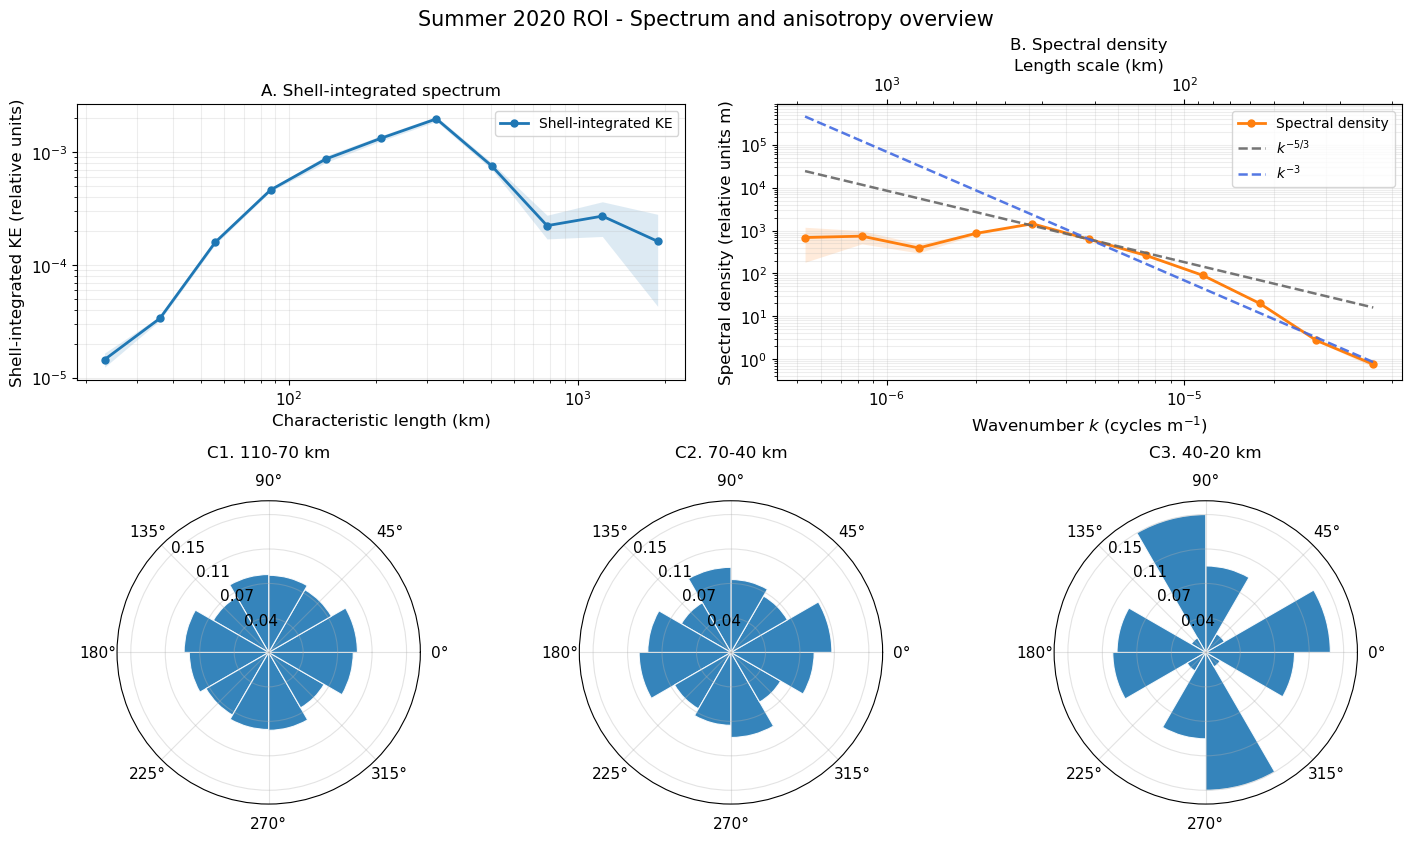

In [31]:
filepath = "../data/GPGP_aug2020.nc"

# lat_s, lat_n = 22.14, 23.86
# lon_w, lon_e = -140.94, -139.06
lat_s, lat_n = 20.0, 45.0 # whole GPGP
lon_w, lon_e = -155.0, -130.0 # whole GPGP

box = [lon_w, lon_e, lat_s, lat_n]


eds = calculate_EDS(
    filepath=filepath,
    target_box=box,
    initialized_velocity=False,
    max_wavelength_km=None,
    n_bins=12,
    remove_mean=True,
    temporal_window_days=1,
    temporal_skip_days=1,
    temporal_stride_days=2,
    min_modes_per_bin=3,
    rose_scale_bands_km=[(110, 70), (70, 40), (40, 20)],
    rose_n_angle_bins=12,
)

plot_eds_overview(eds, title="Summer 2020 ROI - Spectrum and anisotropy overview")

C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_31344\2091877265.py:280: RuntimeWarning: Mean of empty slice
  window_shell_means.append(np.nanmean(spectra_shell[idx, :], axis=0))
C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_31344\2091877265.py:281: RuntimeWarning: Mean of empty slice
  window_density_means.append(np.nanmean(spectra_density[idx, :], axis=0))
C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_31344\2091877265.py:282: RuntimeWarning: Mean of empty slice
  window_axis_means.append(np.nanmean(spectra_axis_complex[idx, :], axis=0))
C:\Users\Jelle Gortemaker\AppData\Local\Temp\ipykernel_31344\2091877265.py:293: RuntimeWarning: Mean of empty slice
  mean_shell = np.nanmean(window_shell_means, axis=0)
c:\Users\Jelle Gortemaker\miniconda3\envs\thesis_parcels\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Jelle Gortemaker\AppData

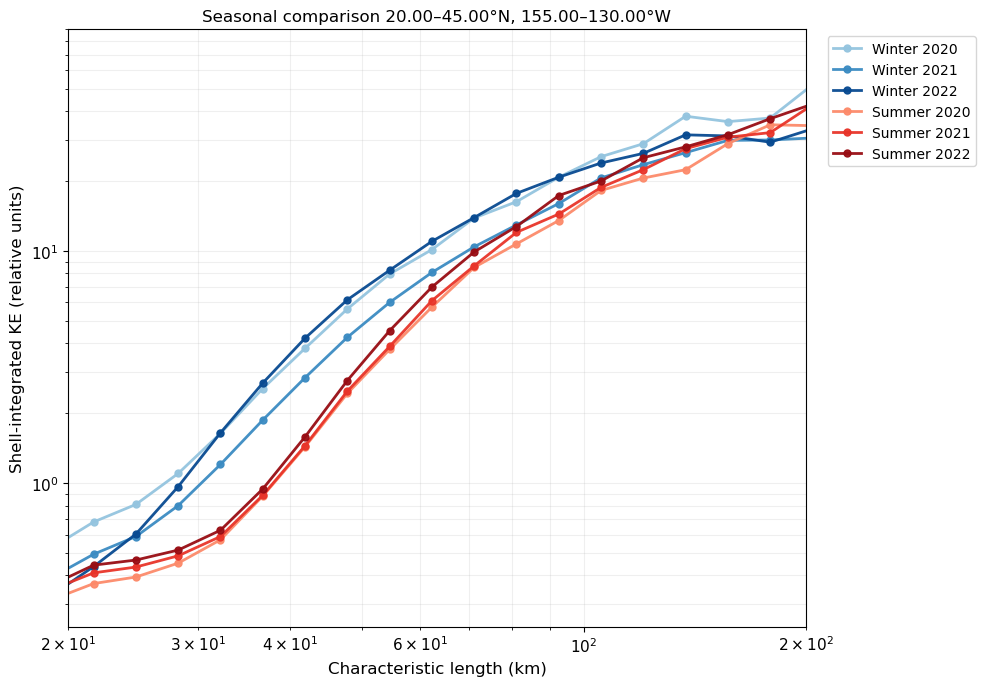

In [ ]:
data_groups = {
    "Winter": {
        "2020": "../data/GPGP_jan2020.nc",
        "2021": "../data/GPGP_jan2021.nc",
        "2022": "../data/GPGP_jan2022.nc",
    },
    "Summer": {
        "2020": "../data/GPGP_aug2020.nc",
        "2021": "../data/GPGP_aug2021.nc",
        "2022": "../data/GPGP_aug2022.nc",
    },
}

plot_EDS_seasonal(
    data_groups=data_groups,
    target_box=box,
    initialized_velocity=False,
    max_wavelength_km=None,
    n_bins=40,
    remove_mean=True,
    temporal_window_days=1,
    temporal_skip_days=0,
    temporal_stride_days=1,
    min_modes_per_bin=3,
    spectrum_var="shell_integrated_spectrum",
    title=f"Seasonal comparison {lat_s:.2f}–{lat_n:.2f}°N, {abs(lon_w):.2f}–{abs(lon_e):.2f}°W",
    xlim_km=(20, 200),
)